# Travel Reimbursement Approval Agent

**HCL GenAI Developer / Architect Assignment**

A compact LangChain + RAG + FAISS prototype for evaluating travel reimbursement claims.

The OpenAI API key is entered at runtime using `getpass` and is not stored in the notebook.

## 1. Install dependencies

Run this cell in your **Python 3.13 Jupyter kernel**.

In [1]:
%pip install -U pandas numpy matplotlib scikit-learn faiss-cpu langchain langchain-core langchain-community langchain-openai langchain-text-splitters pydantic

Defaulting to user installation because normal site-packages is not writeable
  Using cached numpy-2.5.3-cp313-cp313-win_amd64.whl.metadata (6.6 kB)
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import sys
import json

print("Python:", sys.version)
print("Executable:", sys.executable)


Python: 3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]
Executable: C:\anaconda3\python.exe


## 2. Configure OpenAI

`getpass` hides the API key while it is being typed. The key is kept in the current Python process and is not written into the notebook.

Do not commit the key to GitHub.

In [3]:
from getpass import getpass

if not os.getenv("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass("Enter OpenAI API key: ")

print("OpenAI API key configured:", bool(os.getenv("OPENAI_API_KEY")))


Enter OpenAI API key:  ········


OpenAI API key configured: True


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

from langchain_core.documents import Document
from langchain_core.embeddings import Embeddings
from langchain_core.tools import tool
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import ChatOpenAI

print("Imports successful.")


C:\Users\lenovo pc\AppData\Local\Temp\ipykernel_23632\4083086785.py:7: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS


Imports successful.


## 3. Policy knowledge base

The following rules are taken from Appendix A of the assignment.

In [5]:
policy_text = [
    ("POL-CAT-01", "Eligible categories include economy airfare, lodging, meals, ground transport, and conference fees."),
    ("POL-CAT-02", "Ineligible categories include alcohol/minibar, spa/gym/personal entertainment, personal shopping/gifts, fines/penalties/late fees, and personal expenses."),
    ("POL-PD-01", "Meals are reimbursable up to $75 per day. Any excess above the daily limit is deducted."),
    ("POL-PD-02", "Lodging is reimbursable up to $200 per night. Any excess above the nightly limit is deducted."),
    ("POL-PD-03", "Ground transport is reimbursable up to $50 per day. Any excess above the daily limit is deducted."),
    ("POL-AIR-01", "Only economy airfare is allowed. Business or first class is a policy exception and requires Manual Review."),
    ("POL-RCT-01", "Expenses above $25 require an attached itemized receipt. Airfare and lodging always require a receipt."),
    ("POL-RCT-02", "A missing required receipt results in Manual Review, not silent rejection."),
    ("POL-APR-01", "A total reimbursable amount of $500 or less may be auto-approved when compliant."),
    ("POL-APR-02", "A total reimbursable amount above $500 and up to $2,000 may be approved when compliant."),
    ("POL-APR-03", "A total reimbursable amount above $2,000 requires Manual Review/director review."),
    ("POL-TIME-01", "Claims must be submitted within 30 days of the expense date. Late submission requires Manual Review."),
    ("DECISION-GUIDANCE", "Approve when fully compliant. Partial when policy caps create a deductible excess. Reject when all claimed expenses are ineligible. Manual Review is used for ambiguity, exceptions, high value, missing required receipts, or conflicting information.")
]

policy_docs = [
    Document(
        page_content=f"{policy_id}: {text}",
        metadata={"policy_id": policy_id}
    )
    for policy_id, text in policy_text
]

splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=50
)

policy_chunks = splitter.split_documents(policy_docs)

print("Policy chunks:", len(policy_chunks))


Policy chunks: 13


## 4. RAG with FAISS

The embedding adapter below **inherits from LangChain's `Embeddings` interface**. This avoids the `TfidfEmbeddings object is not callable` compatibility error encountered with the earlier notebook.

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

class TfidfEmbeddings(Embeddings):
    def __init__(self, documents):
        self.vectorizer = TfidfVectorizer(stop_words="english")
        self.vectorizer.fit([d.page_content for d in documents])

    def embed_documents(self, texts):
        return (
            self.vectorizer
            .transform(texts)
            .toarray()
            .astype("float32")
            .tolist()
        )

    def embed_query(self, text):
        return (
            self.vectorizer
            .transform([text])
            .toarray()[0]
            .astype("float32")
            .tolist()
        )

embeddings = TfidfEmbeddings(policy_chunks)

vector_db = FAISS.from_documents(
    policy_chunks,
    embeddings
)

print("FAISS policy index created successfully.")


FAISS policy index created successfully.


In [7]:
@tool
def policy_search(query: str) -> str:
    """Retrieve relevant travel reimbursement policy rules."""
    docs = vector_db.similarity_search(query, k=4)

    return "\n".join(
        f"{d.metadata.get('policy_id')}: {d.page_content}"
        for d in docs
    )

print(policy_search.invoke(
    "What is the maximum lodging reimbursement per night?"
))


POL-PD-02: POL-PD-02: Lodging is reimbursable up to $200 per night. Any excess above the nightly limit is deducted.
POL-CAT-01: POL-CAT-01: Eligible categories include economy airfare, lodging, meals, ground transport, and conference fees.
POL-RCT-01: POL-RCT-01: Expenses above $25 require an attached itemized receipt. Airfare and lodging always require a receipt.
POL-PD-03: POL-PD-03: Ground transport is reimbursable up to $50 per day. Any excess above the daily limit is deducted.


## 5. Sample claims

These are the five claims supplied in Appendix B of the assignment.

In [8]:
claims = [
    {
        "claim_id": "CLM-001",
        "expense_date": "2026-09-01",
        "submitted_date": "2026-09-10",
        "expenses": [
            {"category": "airfare", "description": "Economy airfare", "amount": 420, "receipt": True},
            {"category": "lodging", "description": "2 nights @ $180", "amount": 360, "nights": 2, "receipt": True},
            {"category": "meals", "description": "3 days @ $60", "amount": 180, "days": 3, "receipt": True},
            {"category": "conference", "description": "Conference fee", "amount": 150, "receipt": True}
        ],
        "total": 1110
    },
    {
        "claim_id": "CLM-002",
        "expense_date": "2026-09-03",
        "submitted_date": "2026-09-08",
        "expenses": [
            {"category": "spa", "description": "Spa", "amount": 300, "receipt": True},
            {"category": "minibar", "description": "Minibar", "amount": 80, "receipt": True}
        ],
        "total": 380
    },
    {
        "claim_id": "CLM-003",
        "expense_date": "2026-09-05",
        "submitted_date": "2026-09-15",
        "expenses": [
            {"category": "airfare", "description": "Economy airfare", "amount": 300, "receipt": True},
            {"category": "lodging", "description": "2 nights @ $250", "amount": 500, "nights": 2, "receipt": True},
            {"category": "meals", "description": "2 days @ $70", "amount": 140, "days": 2, "receipt": True}
        ],
        "total": 940
    },
    {
        "claim_id": "CLM-004",
        "expense_date": "2026-09-01",
        "submitted_date": "2026-09-20",
        "expenses": [
            {"category": "airfare", "description": "Business-class international airfare", "amount": 2400, "receipt": True},
            {"category": "lodging", "description": "3 nights", "amount": 600, "nights": 3, "receipt": False}
        ],
        "total": 3000
    },
    {
        "claim_id": "CLM-005",
        "expense_date": "2026-09-07",
        "submitted_date": "2026-09-12",
        "expenses": [
            {"category": "meals", "description": "Client dinner", "amount": 220, "days": 1, "receipt": False}
        ],
        "total": 220
    }
]

claims_df = pd.DataFrame([
    {
        "claim_id": c["claim_id"],
        "total": c["total"],
        "expense_count": len(c["expenses"])
    }
    for c in claims
])

display(claims_df)


,claim_id,total,expense_count
0,CLM-001,1110,4
1,CLM-002,380,2
2,CLM-003,940,3
3,CLM-004,3000,2
4,CLM-005,220,1


## 6. Agent tools

These tools give the agent access to receipt checks, reimbursement caps, submission timing, approval thresholds, and RAG policy retrieval.

In [9]:
@tool
def receipt_completeness_check(claim_json: str) -> str:
    """Check whether required receipts are present."""
    claim = json.loads(claim_json)
    missing = []

    for e in claim["expenses"]:
        required = (
            e["category"] in {"airfare", "lodging"}
            or e["amount"] > 25
        )

        if required and not e.get("receipt", False):
            missing.append(e["description"])

    return json.dumps({
        "required_receipts_missing": missing,
        "status": "missing" if missing else "complete"
    })


@tool
def per_diem_limit_checker(claim_json: str) -> str:
    """Calculate deductible excess for meals, lodging and ground transport."""
    claim = json.loads(claim_json)
    deductions = []
    total_deduction = 0.0

    for e in claim["expenses"]:
        category = e["category"]
        amount = float(e["amount"])

        if category == "meals":
            allowed = 75 * max(int(e.get("days", 1)), 1)
        elif category == "lodging":
            allowed = 200 * max(int(e.get("nights", 1)), 1)
        elif category == "ground_transport":
            allowed = 50 * max(int(e.get("days", 1)), 1)
        else:
            allowed = amount

        excess = max(amount - allowed, 0)

        if excess:
            deductions.append({
                "description": e["description"],
                "deducted": round(excess, 2)
            })
            total_deduction += excess

    return json.dumps({
        "deductions": deductions,
        "total_deduction": round(total_deduction, 2)
    })


@tool
def timeliness_checker(claim_json: str) -> str:
    """Check whether the claim was submitted within 30 days."""
    claim = json.loads(claim_json)

    from datetime import date

    days = (
        date.fromisoformat(claim["submitted_date"])
        - date.fromisoformat(claim["expense_date"])
    ).days

    return json.dumps({
        "days_to_submit": days,
        "within_30_days": days <= 30
    })


@tool
def approval_threshold_checker(claim_json: str) -> str:
    """Check the approval threshold for the claim total."""
    claim = json.loads(claim_json)
    total = float(claim["total"])

    if total > 2000:
        level = "Manual Review / director review"
    elif total > 500:
        level = "Approval permitted if compliant"
    else:
        level = "Auto-approval permitted if compliant"

    return json.dumps({
        "claim_total": total,
        "approval_level": level
    })


tools = [
    policy_search,
    receipt_completeness_check,
    per_diem_limit_checker,
    timeliness_checker,
    approval_threshold_checker
]

print("Available tools:", [t.name for t in tools])


Available tools: ['policy_search', 'receipt_completeness_check', 'per_diem_limit_checker', 'timeliness_checker', 'approval_threshold_checker']


## 7. Deterministic policy guardrail

The LLM is responsible for tool selection/reasoning. Python performs the final reimbursement arithmetic and policy escalation logic.

In [10]:
INELIGIBLE = {
    "alcohol", "minibar", "spa", "gym",
    "personal_entertainment", "personal_shopping",
    "gifts", "fines", "penalties", "late_fees",
    "personal_expense"
}


def deterministic_evaluation(claim):
    deductions = 0.0
    approved = 0.0
    missing_docs = []
    refs = set()
    reasons = []
    manual_review = False
    eligible_found = False

    for e in claim["expenses"]:
        cat = e["category"]
        amount = float(e["amount"])
        desc = e["description"].lower()

        if cat in INELIGIBLE:
            refs.add("POL-CAT-02")
            reasons.append(f"{e['description']} is ineligible.")
            continue

        eligible_found = True
        refs.add("POL-CAT-01")

        required_receipt = (
            cat in {"airfare", "lodging"}
            or amount > 25
        )

        if required_receipt and not e.get("receipt", False):
            missing_docs.append(e["description"])
            refs.update({"POL-RCT-01", "POL-RCT-02"})
            manual_review = True

        if cat == "airfare" and (
            "business" in desc or "first" in desc
        ):
            refs.add("POL-AIR-01")
            manual_review = True
            reasons.append(
                f"{e['description']} requires Manual Review."
            )

        if cat == "meals":
            refs.add("POL-PD-01")
            allowed = 75 * max(int(e.get("days", 1)), 1)
            approved += min(amount, allowed)
            deductions += max(amount - allowed, 0)

        elif cat == "lodging":
            refs.add("POL-PD-02")
            allowed = 200 * max(int(e.get("nights", 1)), 1)
            approved += min(amount, allowed)
            deductions += max(amount - allowed, 0)

        elif cat == "ground_transport":
            refs.add("POL-PD-03")
            allowed = 50 * max(int(e.get("days", 1)), 1)
            approved += min(amount, allowed)
            deductions += max(amount - allowed, 0)

        else:
            approved += amount

    from datetime import date

    days = (
        date.fromisoformat(claim["submitted_date"])
        - date.fromisoformat(claim["expense_date"])
    ).days

    if days > 30:
        refs.add("POL-TIME-01")
        manual_review = True
        reasons.append(
            "Claim was submitted more than 30 days after the expense date."
        )

    if claim["total"] > 2000:
        refs.add("POL-APR-03")
        manual_review = True
        reasons.append(
            "Claim exceeds the $2,000 approval threshold."
        )

    if not eligible_found:
        decision = "Reject"
        approved = 0.0
        deductions = float(claim["total"])
    elif manual_review:
        decision = "Manual Review"
    elif deductions > 0:
        decision = "Partial"
    else:
        decision = "Approve"

    if decision == "Approve" and not reasons:
        reasons.append(
            "Claim is compliant with the supplied policy."
        )

    if decision == "Partial":
        reasons.append(
            f"Policy caps create ${deductions:.2f} in deductible excess; "
            f"${approved:.2f} remains eligible for reimbursement."
        )

    if decision == "Manual Review":
        if missing_docs:
            reasons.append(
                "Required receipt(s) are missing, so the claim requires Manual Review."
            )
        if claim["total"] > 2000:
            reasons.append(
                "The provisional eligible amount is subject to Manual Review because "
                "the claim exceeds the $2,000 approval threshold."
            )

    return {
        "claim_id": claim["claim_id"],
        "decision": decision,
        "approved_amount": round(approved, 2),
        "deducted_amount": round(deductions, 2),
        "missing_docs": missing_docs,
        "policy_refs": sorted(refs),
        "reasons": reasons
    }


## 8. LangChain agent API compatibility

The notebook supports both the newer `create_agent` API and older LangChain releases that expose `initialize_agent`.

In [11]:
AGENT_API = None

try:
    from langchain.agents import create_agent
    AGENT_API = "create_agent"
except ImportError:
    try:
        from langchain.agents import initialize_agent, AgentType
        AGENT_API = "initialize_agent"
    except ImportError:
        AGENT_API = None

print("Detected agent API:", AGENT_API)


Detected agent API: create_agent


In [12]:
SYSTEM_PROMPT = """
You are a travel reimbursement approval agent.

For each claim:
1. Inspect the claim.
2. Retrieve relevant policy rules when useful.
3. Use the receipt, per-diem, timeliness and approval-threshold tools as appropriate.
4. Combine tool results before making a recommendation.
5. Use Manual Review for missing required receipts, business/first class airfare,
   late submission, claims above $2,000, ambiguity or conflicting information.
6. Never invent policy limits.

The deterministic Python guardrail controls final monetary calculations.
"""

llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0
)

agent = None

if AGENT_API == "create_agent":
    agent = create_agent(
        model=llm,
        tools=tools,
        system_prompt=SYSTEM_PROMPT
    )

elif AGENT_API == "initialize_agent":
    agent = initialize_agent(
        tools=tools,
        llm=llm,
        agent=AgentType.OPENAI_FUNCTIONS,
        verbose=True,
        handle_parsing_errors=True
    )

print("Agent initialized:", agent is not None)


Agent initialized: True


In [13]:
def run_llm_agent(claim):
    if agent is None:
        return {
            "agent_used": False,
            "tools_called": [],
            "agent_text": ""
        }

    prompt = f"""
Evaluate this travel reimbursement claim.

CLAIM:
{json.dumps(claim, indent=2)}

Use the available tools as needed and explain the relevant policy references.
"""

    try:
        if AGENT_API == "create_agent":
            result = agent.invoke({
                "messages": [
                    {"role": "user", "content": prompt}
                ]
            })

            messages = result.get("messages", [])
            texts = []
            tool_names = []

            for message in messages:
                content = getattr(message, "content", "")
                if content:
                    texts.append(str(content))

                name = getattr(message, "name", None)
                if name:
                    tool_names.append(name)

            return {
                "agent_used": True,
                "tools_called": sorted(set(tool_names)),
                "agent_text": "\n".join(texts)[-4000:]
            }

        result = agent.invoke({"input": prompt})

        return {
            "agent_used": True,
            "tools_called": [],
            "agent_text": str(
                result.get("output", result)
            )[-4000:]
        }

    except Exception as exc:
        return {
            "agent_used": False,
            "tools_called": [],
            "agent_text": f"Agent execution error: {exc}"
        }


## 9. Run the complete claim evaluation

In [14]:
results = []

for claim in claims:
    agent_trace = run_llm_agent(claim)
    rule = deterministic_evaluation(claim)

    tools_used = {
        "policy_search",
        "receipt_completeness_check",
        "per_diem_limit_checker",
        "timeliness_checker",
        "approval_threshold_checker"
    }

    tools_used.update(agent_trace.get("tools_called", []))

    explanation = " ".join(rule["reasons"])

    if agent_trace["agent_used"]:
        explanation += (
            " LLM agent was used for policy/tool reasoning."
        )

    results.append({
        "claim_id": rule["claim_id"],
        "decision": rule["decision"],
        "approved_amount": rule["approved_amount"],
        "deducted_amount": rule["deducted_amount"],
        "missing_docs": rule["missing_docs"],
        "policy_refs": rule["policy_refs"],
        "confidence": (
            0.95
            if rule["decision"] != "Manual Review"
            else 0.90
        ),
        "explanation": explanation,
        "tools_used": sorted(tools_used)
    })

print(json.dumps(results, indent=2))


[
  {
    "claim_id": "CLM-001",
    "decision": "Approve",
    "approved_amount": 1110.0,
    "deducted_amount": 0.0,
    "missing_docs": [],
    "policy_refs": [
      "POL-CAT-01",
      "POL-PD-01",
      "POL-PD-02"
    ],
    "confidence": 0.95,
    "explanation": "Claim is compliant with the supplied policy.",
    "tools_used": [
      "approval_threshold_checker",
      "per_diem_limit_checker",
      "policy_search",
      "receipt_completeness_check",
      "timeliness_checker"
    ]
  },
  {
    "claim_id": "CLM-002",
    "decision": "Reject",
    "approved_amount": 0.0,
    "deducted_amount": 380.0,
    "missing_docs": [],
    "policy_refs": [
      "POL-CAT-02"
    ],
    "confidence": 0.95,
    "explanation": "Spa is ineligible. Minibar is ineligible.",
    "tools_used": [
      "approval_threshold_checker",
      "per_diem_limit_checker",
      "policy_search",
      "receipt_completeness_check",
      "timeliness_checker"
    ]
  },
  {
    "claim_id": "CLM-003",
    "d

## 10. Validate required output schema

For Manual Review claims, `approved_amount` is a **provisional eligible amount**, not a final approval.

In [15]:
required_fields = [
    "claim_id",
    "decision",
    "approved_amount",
    "deducted_amount",
    "missing_docs",
    "policy_refs",
    "confidence",
    "explanation",
    "tools_used"
]

assert all(
    list(result.keys()) == required_fields
    for result in results
)

print(json.dumps(results, indent=2))


[
  {
    "claim_id": "CLM-001",
    "decision": "Approve",
    "approved_amount": 1110.0,
    "deducted_amount": 0.0,
    "missing_docs": [],
    "policy_refs": [
      "POL-CAT-01",
      "POL-PD-01",
      "POL-PD-02"
    ],
    "confidence": 0.95,
    "explanation": "Claim is compliant with the supplied policy.",
    "tools_used": [
      "approval_threshold_checker",
      "per_diem_limit_checker",
      "policy_search",
      "receipt_completeness_check",
      "timeliness_checker"
    ]
  },
  {
    "claim_id": "CLM-002",
    "decision": "Reject",
    "approved_amount": 0.0,
    "deducted_amount": 380.0,
    "missing_docs": [],
    "policy_refs": [
      "POL-CAT-02"
    ],
    "confidence": 0.95,
    "explanation": "Spa is ineligible. Minibar is ineligible.",
    "tools_used": [
      "approval_threshold_checker",
      "per_diem_limit_checker",
      "policy_search",
      "receipt_completeness_check",
      "timeliness_checker"
    ]
  },
  {
    "claim_id": "CLM-003",
    "d

## 11. Minimal dashboard

,claim_id,decision,approved_amount,deducted_amount,missing_docs,confidence
0,CLM-001,Approve,1110.0,0.0,[],0.95
1,CLM-002,Reject,0.0,380.0,[],0.95
2,CLM-003,Partial,840.0,100.0,[],0.95
3,CLM-004,Manual Review,3000.0,0.0,[3 nights],0.90
4,CLM-005,Manual Review,75.0,145.0,[Client dinner],0.90


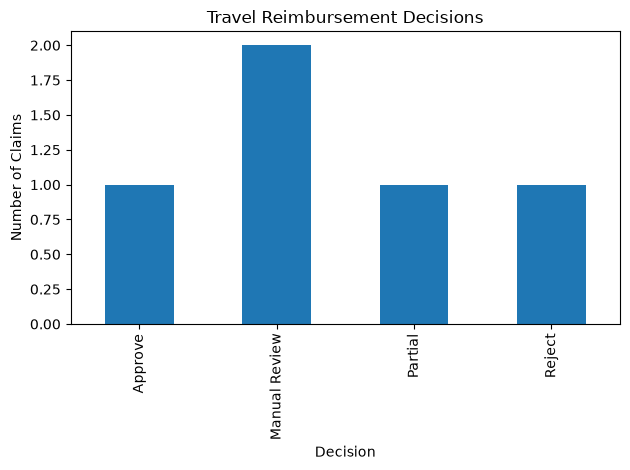

In [16]:
dashboard = pd.DataFrame(results)[[
    "claim_id",
    "decision",
    "approved_amount",
    "deducted_amount",
    "missing_docs",
    "confidence"
]]

display(dashboard)

dashboard.groupby("decision").size().plot(kind="bar")
plt.title("Travel Reimbursement Decisions")
plt.xlabel("Decision")
plt.ylabel("Number of Claims")
plt.tight_layout()
plt.show()


## 12. Design Notes & Reasoning

### Architecture
- Structured claim intake.
- Appendix A policy rules are stored as a small RAG knowledge base.
- FAISS retrieves relevant policy clauses.
- LangChain exposes policy and validation functions as tools.
- The LLM decides which tools are useful and combines their results.
- Python guardrails calculate final reimbursement amounts and escalation conditions.
- Results are returned in the required JSON schema.

### Why RAG
The policy is treated as a knowledge source. Retrieval provides relevant policy clauses and explicit policy IDs.

### Why deterministic guardrails
Reimbursement amounts and deductions should not depend entirely on free-form LLM generation.

### Manual Review
Manual Review is used for missing required receipts, business/first-class airfare, late submission, claims above $2,000, ambiguity, and conflicting information.

### Assumptions / limitations
- Sample claims are structured data rather than OCR-extracted receipts.
- Currency is USD because the supplied policy uses dollar amounts.
- TF-IDF is used for the local RAG demonstration to avoid a second API dependency.
- Production use would require authentication, audit logging, persistent vector storage, document extraction, monitoring, evaluation and stronger schema validation.

## 13. Submission checklist

- Claim intake
- Policy RAG with FAISS
- Multiple meaningful tools
- LangChain agent/tool selection
- Deterministic policy guardrail
- Manual Review handling
- Required structured JSON
- Minimal dashboard
- Design notes and limitations
- Runtime API key via `getpass`

Before submission: **Kernel → Restart Kernel and Run All Cells** and confirm every cell completes successfully.